Dataset Visualization
DISTRIBUTIONS & INFO

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (replace the file path with your actual file path)
file_path = "Day2Data.csv"
df = pd.read_csv(file_path)
df

,Timestamp,ServingCellID,PCellRSRP,PCellRSRQ,NeighCellId,NeighCellRSRP,NeighCellRSRQ,Handover,CINRvalue1,CINRvalue2,CINR
0,46:26.3,50,51,6.0,77,49.0,6.0,0,11,9,10.0
1,46:26.3,50,51,6.0,162,47.0,4.0,0,11,9,10.0
2,46:28.4,50,52,10.0,77,46.0,2.0,0,11,9,10.0
3,46:38.9,50,48,4.0,77,47.0,7.0,0,1,-1,0.0
4,46:39.3,50,51,6.0,77,49.0,6.0,0,2,-4,-1.0
...,...,...,...,...,...,...,...,...,...,...,...
642,32:15.1,306,68,24.0,328,56.0,21.0,1,0,2,1.0
643,32:15.3,328,57,12.0,308,56.0,7.0,0,0,2,1.0
644,32:15.9,328,55,13.0,308,56.0,7.0,0,0,2,1.0
645,32:21.9,328,59,15.0,308,56.0,7.0,0,15,13,14.0


In [93]:
# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Timestamp      647 non-null    object 
 1   ServingCellID  647 non-null    int64  
 2   PCellRSRP      647 non-null    int64  
 3   PCellRSRQ      647 non-null    float64
 4   NeighCellId    647 non-null    int64  
 5   NeighCellRSRP  647 non-null    float64
 6   NeighCellRSRQ  647 non-null    float64
 7   Handover       647 non-null    int64  
 8   CINRvalue1     647 non-null    int64  
 9   CINRvalue2     647 non-null    int64  
 10  CINR           647 non-null    float64
dtypes: float64(4), int64(6), object(1)
memory usage: 55.7+ KB
None

Basic Statistics:
       ServingCellID   PCellRSRP   PCellRSRQ  NeighCellId  NeighCellRSRP  \
count     647.000000  647.000000  647.000000    647.00000     647.000000   
mean      240.740340   51.826893   10.820711    207.16847      50.3724

In [6]:
df.describe().NeighCellRSRQ

count    647.000000
mean       8.168207
std        6.135969
min        0.000000
25%        3.000000
50%        7.000000
75%       13.000000
max       25.000000
Name: NeighCellRSRQ, dtype: float64

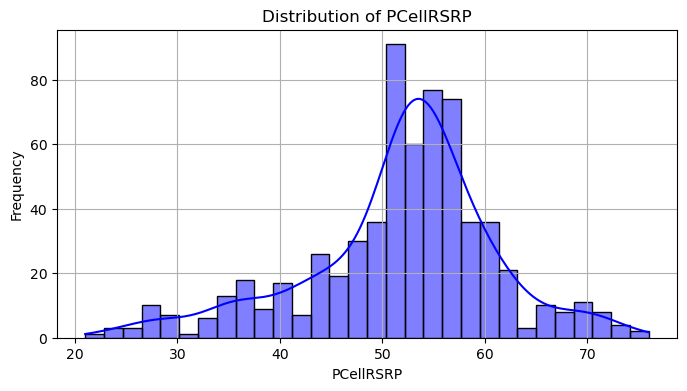

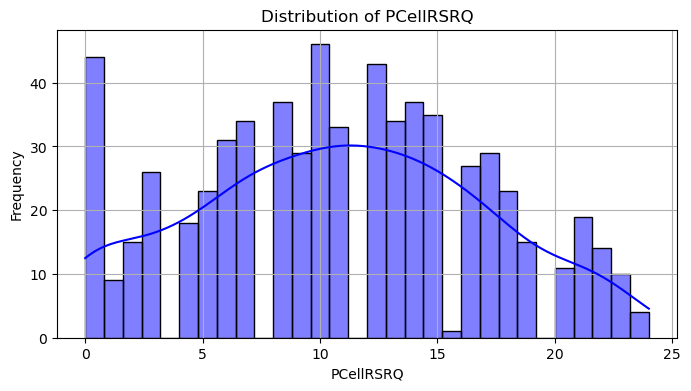

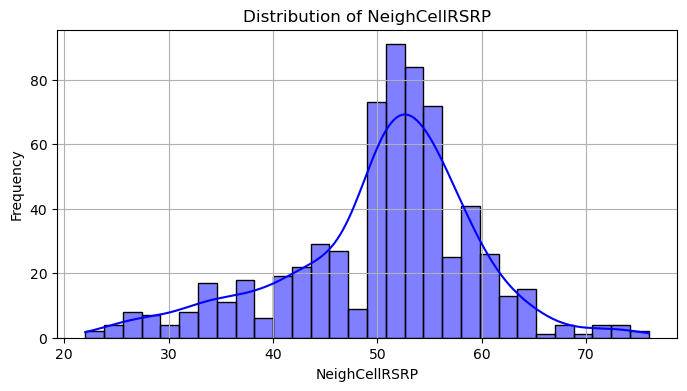

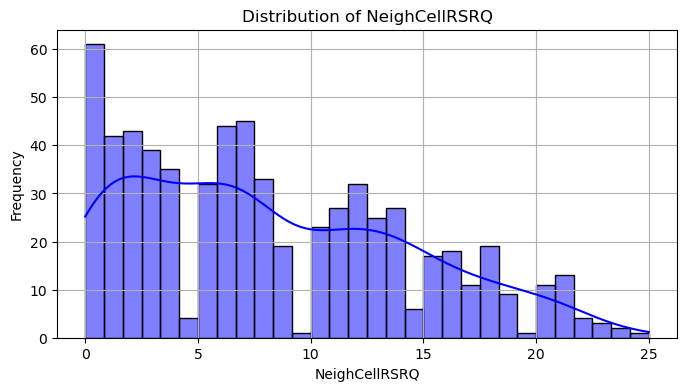

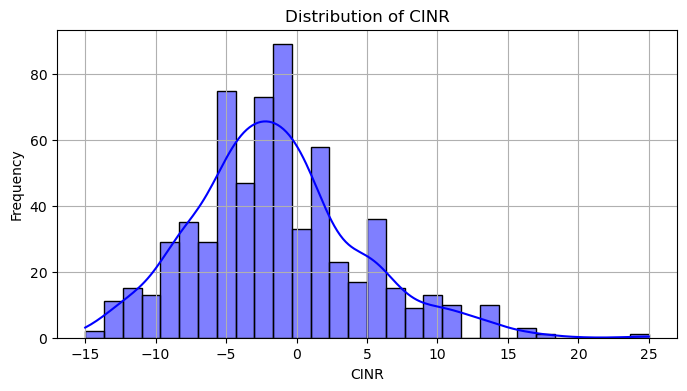

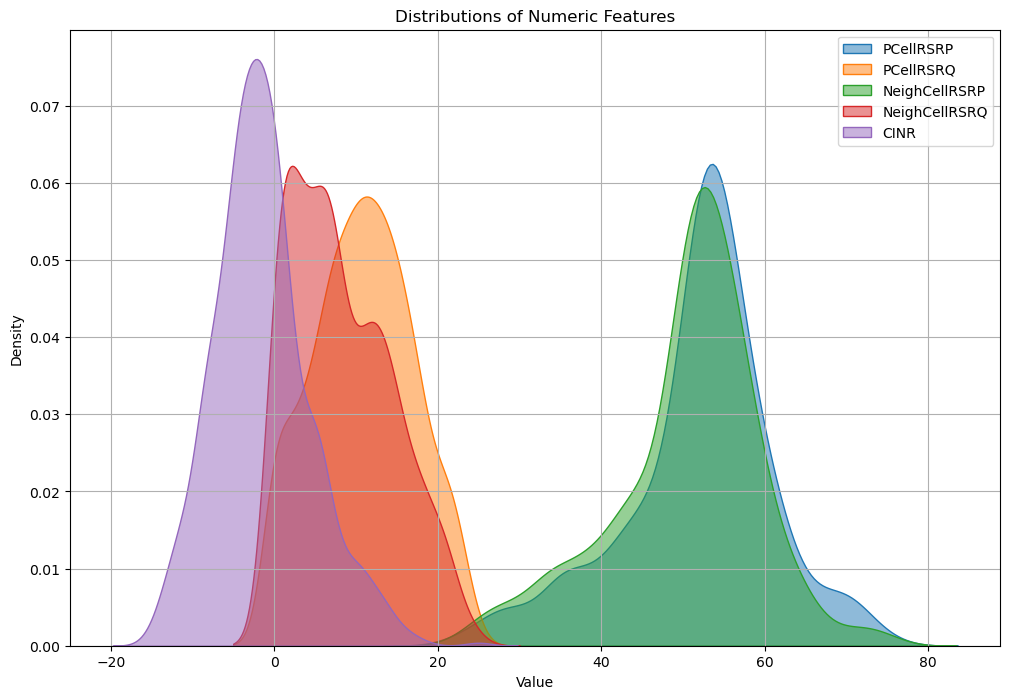

In [4]:
# Plot distribution of numeric features
numeric_features = ['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 
                     'CINR']

for feature in numeric_features:
    if feature in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[feature].dropna(), kde=True, bins=30, color="blue")
        plt.title(f"Distribution of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.grid()
        plt.show()


# Plot all numeric feature distributions in one plot
plt.figure(figsize=(12, 8))

for feature in numeric_features:
    if feature in df.columns:
        sns.kdeplot(df[feature].dropna(), label=feature, fill=True, alpha=0.5)

plt.title("Distributions of Numeric Features")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

CELL ID & HANDOVER COUNTS

In [94]:
import pandas as pd

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df = pd.read_csv(file_path)

# Count unique values for ServingCellID (PCell)
print("Unique ServingCellID (PCell):")
serving_cell_counts = df['ServingCellID'].value_counts()
print(serving_cell_counts)
print(f"Total unique ServingCellID (PCell): {df['ServingCellID'].nunique()}")

# Count unique values for NeighCellId (Neighbor Cell)
print("\nUnique NeighCellId (Neighbor Cell):")
neighbor_cell_counts = df['NeighCellId'].value_counts()
print(neighbor_cell_counts)
print(f"Total unique NeighCellId (Neighbor Cell): {df['NeighCellId'].nunique()}")

# Count the number of handovers (assuming 'Handover' column is binary: 1 for handover, 0 for non-handover)
handover_counts = df['Handover'].value_counts()

print("Handover Counts:")
print(f"Number of Handovers: {handover_counts.get(1, 0)}")
print(f"Number of Non-Handovers: {handover_counts.get(0, 0)}")

Unique ServingCellID (PCell):
ServingCellID
297    111
301     96
152     33
58      32
325     28
305     27
299     25
234     24
365     23
47      22
244     22
196     22
150     16
291     16
33      14
306     13
151     11
235     11
327     11
50       9
195      9
348      8
328      8
34       6
326      6
264      5
57       4
353      4
77       3
292      3
100      3
36       3
197      3
403      3
60       3
349      2
30       2
63       2
371      2
37       1
259      1
Name: count, dtype: int64
Total unique ServingCellID (PCell): 41

Unique NeighCellId (Neighbor Cell):
NeighCellId
299    72
297    68
152    59
301    43
150    38
       ..
124     1
123     1
36      1
60      1
306     1
Name: count, Length: 66, dtype: int64
Total unique NeighCellId (Neighbor Cell): 66
Handover Counts:
Number of Handovers: 94
Number of Non-Handovers: 553


CORRELATION

Correlation Matrix (Without CINRvalue1 and CINRvalue2):
               PCellRSRP  PCellRSRQ  NeighCellRSRP  NeighCellRSRQ  Handover  \
PCellRSRP       1.000000   0.324265       0.781224       0.142154 -0.129956   
PCellRSRQ       0.324265   1.000000       0.106224       0.451617 -0.216411   
NeighCellRSRP   0.781224   0.106224       1.000000       0.289729  0.137923   
NeighCellRSRQ   0.142154   0.451617       0.289729       1.000000  0.265236   
Handover       -0.129956  -0.216411       0.137923       0.265236  1.000000   
CINR            0.136634   0.421401       0.053280       0.280499  0.005687   

                   CINR  
PCellRSRP      0.136634  
PCellRSRQ      0.421401  
NeighCellRSRP  0.053280  
NeighCellRSRQ  0.280499  
Handover       0.005687  
CINR           1.000000  


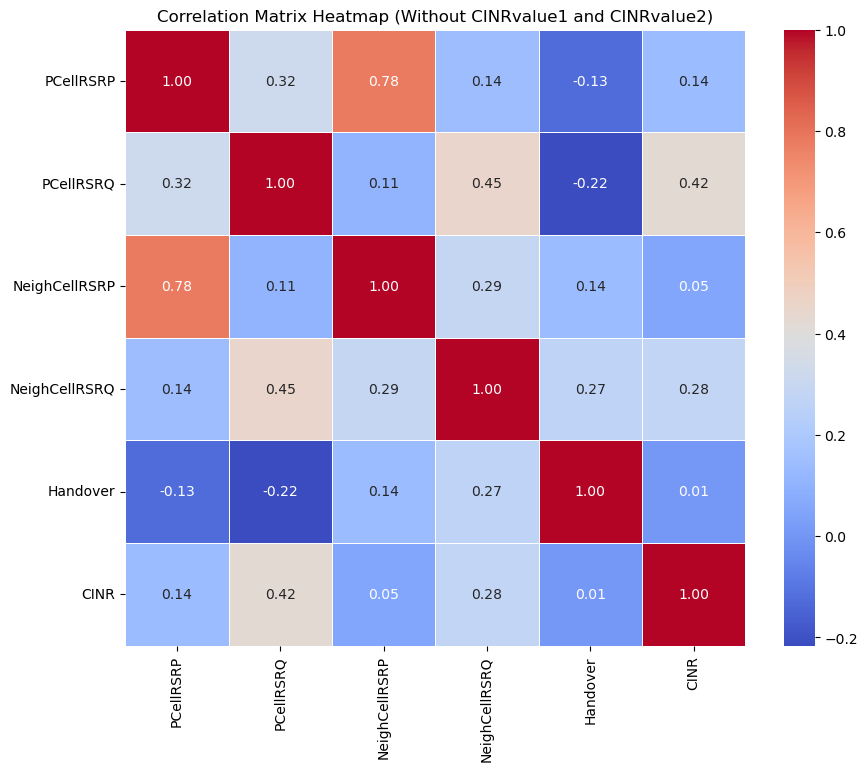

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (replace the file path with your actual file path)
file_path = "Day2Data.csv"
df_original = pd.read_csv(file_path)

# Exclude CINRvalue1 and CINRvalue2
df = df_original.drop(columns=['CINRvalue1', 'CINRvalue2', "Timestamp", "ServingCellID" , "NeighCellId" ], errors='ignore')

# Compute the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print("Correlation Matrix (Without CINRvalue1 and CINRvalue2):")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Without CINRvalue1 and CINRvalue2)")
plt.show()

SCATTER PLOT OF SIGNAL VALUES

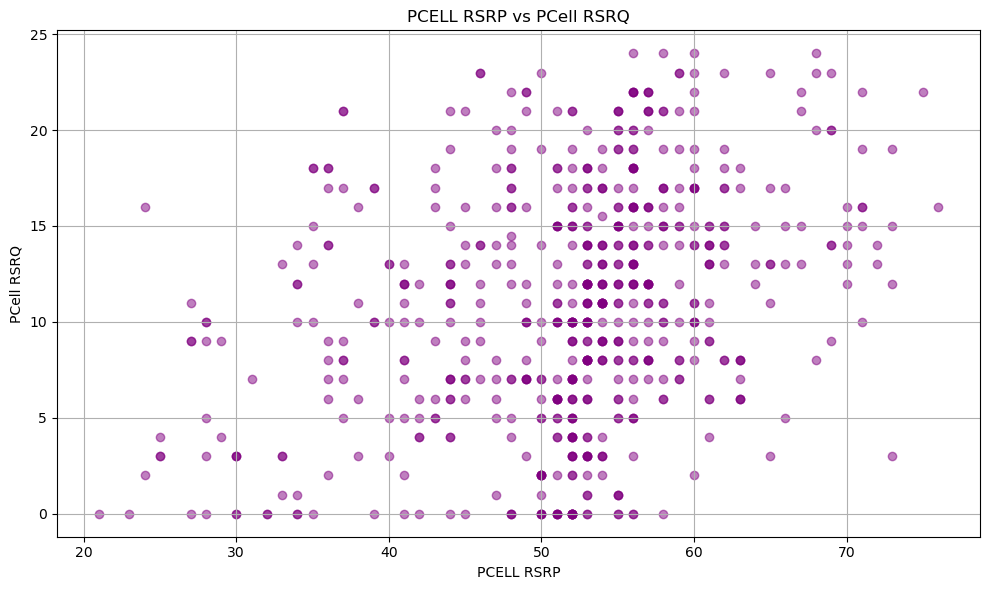

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df_original = pd.read_csv(file_path)

# Drop unnecessary columns (CINRvalue1, CINRvalue2, ServingCellID, NeighCellId)
df = df_original.drop(columns=['CINRvalue1', 'CINRvalue2', 'ServingCellID', 'NeighCellId'], errors='ignore')

# Plotting RCELL RSRP vs PCell RSRQ
plt.figure(figsize=(10, 6))

plt.scatter(df['PCellRSRP'], df['PCellRSRQ'], alpha=0.5, color='purple')
plt.xlabel('PCELL RSRP')
plt.ylabel('PCell RSRQ')
plt.title('PCELL RSRP vs PCell RSRQ')
plt.grid(True)
plt.tight_layout()
plt.show()

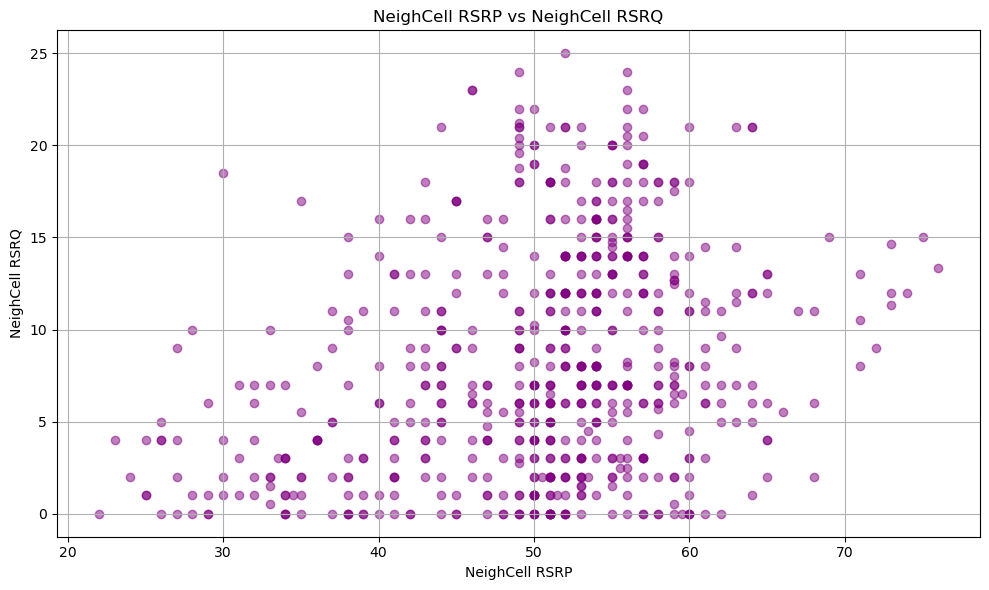

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df_original = pd.read_csv(file_path)

# Drop unnecessary columns (CINRvalue1, CINRvalue2, ServingCellID, NeighCellId)
df = df_original.drop(columns=['CINRvalue1', 'CINRvalue2', 'ServingCellID', 'NeighCellId'], errors='ignore')

# Plotting RCELL RSRP vs PCell RSRQ
plt.figure(figsize=(10, 6))

plt.scatter(df['NeighCellRSRP'], df['NeighCellRSRQ'], alpha=0.5, color='purple')
plt.xlabel('NeighCell RSRP')
plt.ylabel('NeighCell RSRQ')
plt.title('NeighCell RSRP vs NeighCell RSRQ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
HANDOVERS FROM THE SERVING CELL

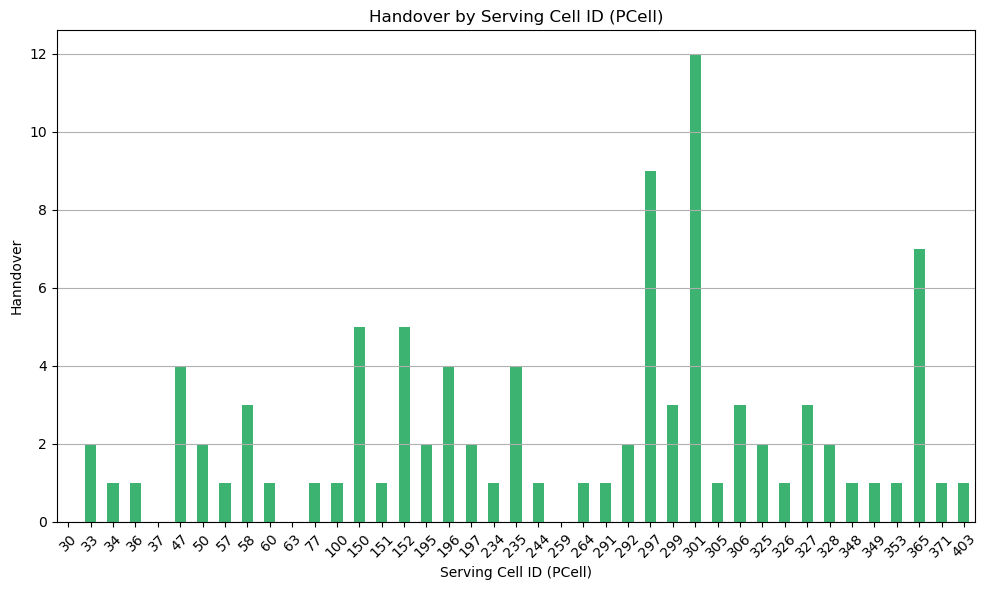

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace with the correct file path)
file_path = "Day2Data.csv"
df = pd.read_csv(file_path)

# Drop unnecessary columns for this task (if any)
df_cleaned = df.drop(columns=['CINRvalue1', 'CINRvalue2', 'Timestamp', 'NeighCellId'], errors='ignore')

# Assuming 'Handover' column contains 1 for successful handover and 0 for failure
# Calculate handover success rate by ServingCellID (PCell)
success_rate_by_cell = df_cleaned.groupby('ServingCellID')['Handover'].sum()

# Plotting Handover Success Rate by ServingCellID (PCell)
plt.figure(figsize=(10, 6))
success_rate_by_cell.plot(kind='bar', color='mediumseagreen')
plt.title('Handover by Serving Cell ID (PCell)')
plt.xlabel('Serving Cell ID (PCell)')
plt.ylabel('Hanndover')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

LOGISTIC REGRESSION

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Logistic Regression model
lr_model = LogisticRegression()

# Fit the model
lr_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class
y_prob

array([0.17180521, 0.08233278, 0.04057151, 0.01793294, 0.16352311,
       0.18653103, 0.02871296, 0.36635566, 0.23305643, 0.74775502,
       0.05282445, 0.04496567, 0.0193066 , 0.07429171, 0.00924306,
       0.00626402, 0.00517621, 0.03456263, 0.00909686, 0.01017333,
       0.73901054, 0.8298185 , 0.00614289, 0.12708068, 0.00490929,
       0.38966966, 0.0947592 , 0.15196745, 0.02464823, 0.61976082,
       0.02209851, 0.39700357, 0.01218751, 0.03231963, 0.21395873,
       0.08950757, 0.08653907, 0.00518875, 0.23635879, 0.00571024,
       0.09056959, 0.00660091, 0.51580387, 0.03316392, 0.02181515,
       0.01575343, 0.01541139, 0.03936435, 0.07453578, 0.18653103,
       0.02273708, 0.1795922 , 0.56958171, 0.02877788, 0.41478147,
       0.42428536, 0.04184021, 0.00460792, 0.19481403, 0.27322003,
       0.06923532, 0.00401404, 0.18914615, 0.24878795, 0.0333738 ,
       0.07125293, 0.38631389, 0.11706547, 0.02007834, 0.05673881,
       0.01252999, 0.02842666, 0.25572659, 0.04673299, 0.03801

In [28]:
# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.4
y_pred = (y_prob >= threshold).astype(int)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [21]:
y_test.head(10)

634    0
220    0
426    0
428    0
72     0
437    0
181    0
131    1
231    0
277    1
Name: Handover, dtype: int64

Threshold: 0.4
Accuracy: 0.9231
Precision: 0.7500
Recall: 0.5625
F1 Score: 0.6429
AUC: 0.8871


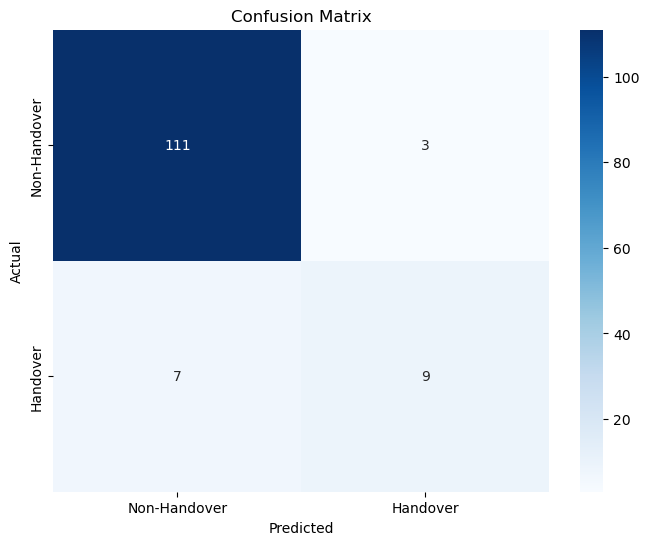

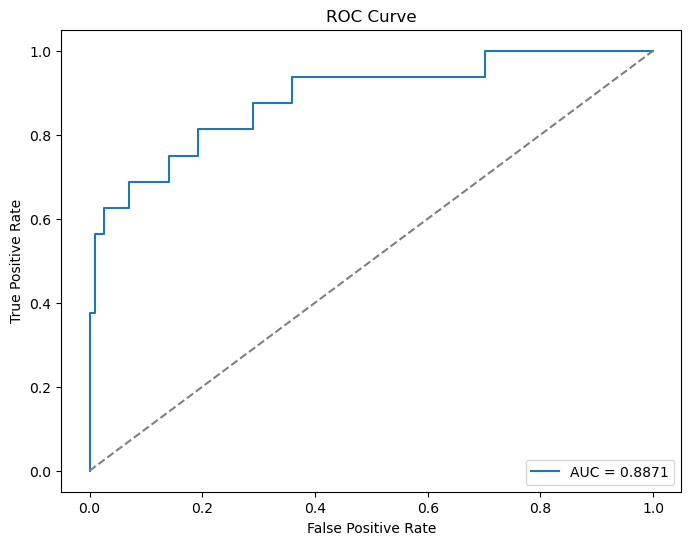

Log Loss: 0.2374


In [29]:
# Evaluate the model with different metrics
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")


KFOLD CROSS VALIDATION

In [25]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the Logistic Regression model
lr_model = LogisticRegression()

# Set threshold for prediction
threshold = 0.3

# K-Fold Cross Validation setup
kf = StratifiedKFold(n_splits=25, shuffle=True, random_state=42)

# Lists to store accuracy and recall scores across all folds
accuracy_scores = []
recall_scores = []

# Perform K-Fold cross-validation
for train_index, test_index in kf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    lr_model.fit(X_train, y_train)
    
    # Predict probabilities on the test set
    y_prob = lr_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    
    # Apply threshold and predict class labels
    y_pred = (y_prob >= threshold).astype(int)
    
    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Store accuracy and recall scores
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Displaying the results
print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")

# Mean and Standard Deviation for Accuracy and Recall
print(f"\nMean Accuracy: {np.mean(accuracy_scores):.4f} | Std Accuracy: {np.std(accuracy_scores):.4f}")
print(f"Mean Recall: {np.mean(recall_scores):.4f} | Std Recall: {np.std(recall_scores):.4f}")


Accuracy Scores: [0.8461538461538461, 0.9230769230769231, 0.9230769230769231, 0.8461538461538461, 0.9230769230769231, 0.8846153846153846, 0.8846153846153846, 0.9615384615384616, 0.7307692307692307, 0.8846153846153846, 0.8076923076923077, 1.0, 0.9230769230769231, 0.8846153846153846, 0.8846153846153846, 0.9230769230769231, 0.9230769230769231, 0.9230769230769231, 0.8461538461538461, 0.8846153846153846, 0.8846153846153846, 0.8461538461538461, 0.92, 0.76, 0.88]
Recall Scores: [0.6666666666666666, 0.6666666666666666, 1.0, 0.75, 0.5, 0.25, 0.5, 0.75, 0.5, 0.5, 0.0, 1.0, 0.5, 0.25, 0.75, 0.75, 0.75, 1.0, 0.5, 0.75, 0.75, 0.5, 0.6666666666666666, 0.3333333333333333, 0.6666666666666666]

Mean Accuracy: 0.8839 | Std Accuracy: 0.0572
Mean Recall: 0.6100 | Std Recall: 0.2365


DECISION TREE

Threshold: 0.3
Accuracy: 0.8615
Precision: 0.4286
Recall: 0.3750
F1 Score: 0.4000
AUC: 0.6524


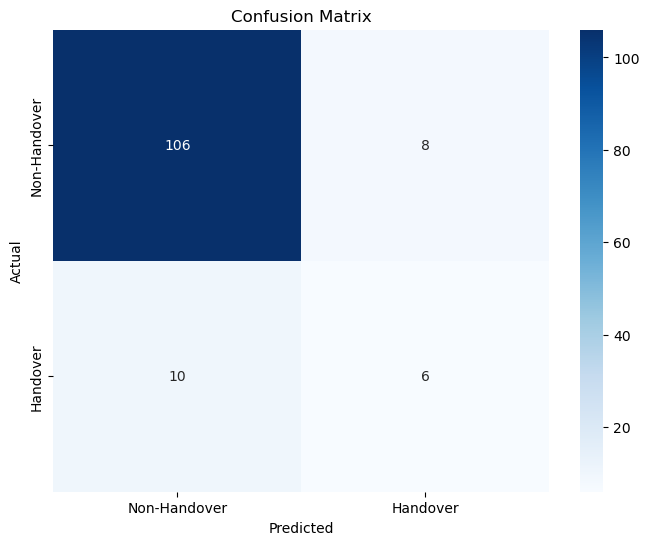

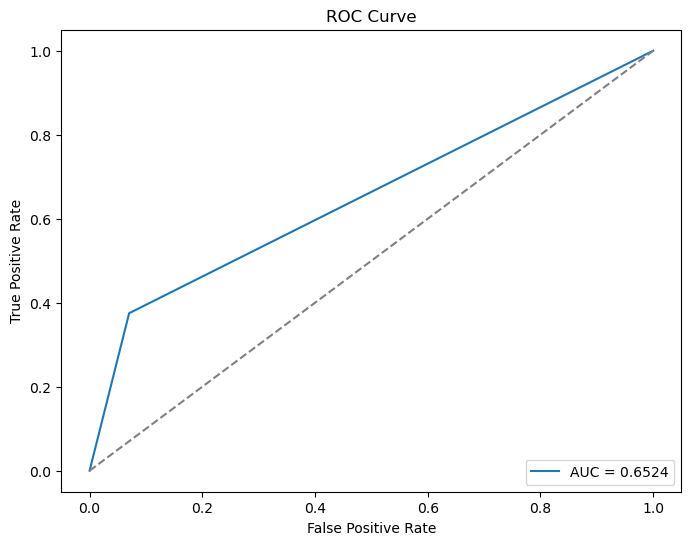

Log Loss: 4.9907


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Features
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing) using stratify to maintain the ratio of handovers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Decision Tree model with class weighting to handle class imbalance
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the model
dt_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = dt_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class (handover)

# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")

KFOLD CROSS VALIDATION

In [82]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Features
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Set threshold for prediction
threshold = 0.3

# K-Fold Cross Validation setup
kf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

# Lists to store metrics across all folds
accuracy_scores = []
recall_scores = []

# Perform K-Fold cross-validation
for train_index, test_index in kf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    dt_model.fit(X_train, y_train)
    
    # Predict probabilities on the test set
    y_prob = dt_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (handover)
    
    # Apply threshold and predict class labels
    y_pred = (y_prob >= threshold).astype(int)
    
    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Store metrics for each fold
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Displaying results for each fold
print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")

# Mean and Std for each metric
print(f"\nMean Accuracy: {np.mean(accuracy_scores):.4f} | Std Accuracy: {np.std(accuracy_scores):.4f}")
print(f"Mean Recall: {np.mean(recall_scores):.4f} | Std Recall: {np.std(recall_scores):.4f}")

Accuracy Scores: [0.7954545454545454, 0.8409090909090909, 0.8372093023255814, 0.8604651162790697, 0.9069767441860465, 0.7906976744186046, 0.7674418604651163, 0.8604651162790697, 0.8372093023255814, 0.8837209302325582, 0.7906976744186046, 0.7906976744186046, 0.7906976744186046, 0.7906976744186046, 0.8372093023255814]
Recall Scores: [0.42857142857142855, 0.5714285714285714, 0.6666666666666666, 0.5, 0.8333333333333334, 0.5, 0.16666666666666666, 0.16666666666666666, 0.6666666666666666, 0.5, 0.3333333333333333, 0.16666666666666666, 0.3333333333333333, 0.2857142857142857, 0.5714285714285714]

Mean Accuracy: 0.8254 | Std Accuracy: 0.0395
Mean Recall: 0.4460 | Std Recall: 0.1955


RANDOM FOREST

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing) using stratify to maintain the ratio of handovers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Fit the model
rf_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class
y_prob

array([0.105     , 0.09      , 0.08      , 0.45      , 0.15      ,
       0.62      , 0.37083333, 0.23      , 0.62      , 0.23      ,
       0.02      , 0.02      , 0.49      , 0.05      , 0.00666667,
       0.45      , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.09      , 0.1       , 0.        , 0.        ,
       0.02      , 0.42      , 0.18      , 0.        , 0.02      ,
       0.        , 0.        , 0.08      , 0.        , 0.25      ,
       0.17      , 0.03      , 0.        , 0.1       , 0.11      ,
       0.03      , 0.21      , 0.01      , 0.        , 0.01      ,
       0.15      , 0.        , 0.02      , 0.02      , 0.11      ,
       0.        , 0.10166667, 0.        , 0.39      , 0.16      ,
       0.15      , 0.        , 0.015     , 0.        , 0.03      ,
       0.05      , 0.        , 0.14      , 0.07      , 0.05      ,
       0.06      , 0.56      , 0.63      , 0.22      , 0.14      ,
       0.12      , 0.2       , 0.09      , 0.3       , 0.13   

In [8]:
# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)
y_pred 

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

In [9]:
y_test

434    0
220    0
298    0
551    1
365    0
      ..
189    0
382    1
10     0
590    0
111    0
Name: Handover, Length: 130, dtype: int64

Threshold: 0.3
Accuracy: 0.8692
Precision: 0.5455
Recall: 0.6316
F1 Score: 0.5854
AUC: 0.8528


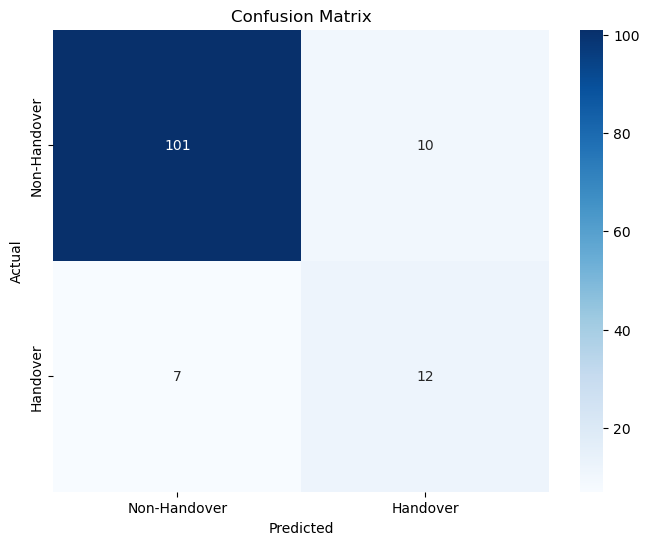

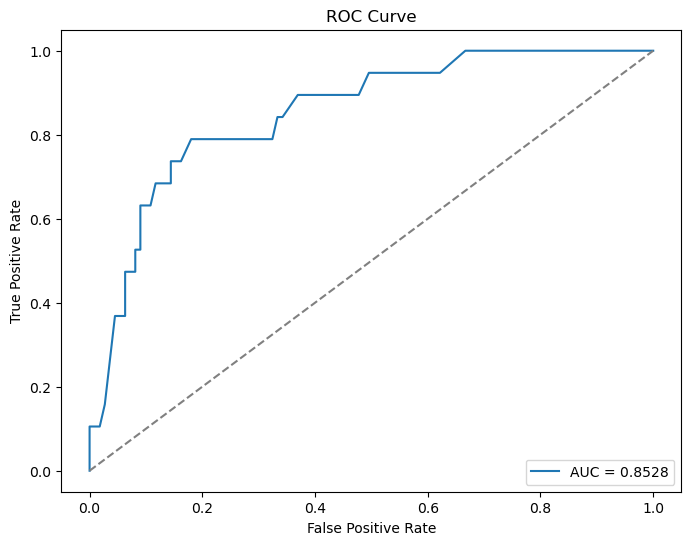

Log Loss: 0.3048


In [10]:
# Evaluate the model with different metrics
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")

KFOLD CROSS VALIDATION

In [77]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score
import numpy as np

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

accuracy_scores = []
recall_scores = []

# Perform Stratified K-Fold cross-validation
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    rf_model.fit(X_train, y_train)

    # Predict probabilities on the test set
    y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

    # Adjust the decision threshold (Th=0.3 instead of 0.5)
    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Calculate the mean and standard deviation for accuracy and recall
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print the formatted output
print(f"Threshold: {threshold}")
print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")
print(f"\nMean Accuracy: {mean_accuracy:.4f} | Std Accuracy: {std_accuracy:.4f}")
print(f"Mean Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f}")


Threshold: 0.3
Accuracy Scores: [0.8636363636363636, 0.9090909090909091, 0.7906976744186046, 0.9302325581395349, 0.9534883720930233, 0.8372093023255814, 0.8604651162790697, 0.9069767441860465, 0.8837209302325582, 0.8604651162790697, 0.813953488372093, 0.8837209302325582, 0.8604651162790697, 0.7674418604651163, 0.8372093023255814]
Recall Scores: [0.7142857142857143, 1.0, 0.3333333333333333, 0.6666666666666666, 0.8333333333333334, 0.6666666666666666, 0.5, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.2857142857142857, 0.5714285714285714]

Mean Accuracy: 0.8639 | Std Accuracy: 0.0488
Mean Recall: 0.6381 | Std Recall: 0.1677


SVM

Threshold: 0.3
Accuracy: 0.8923
Precision: 0.5455
Recall: 0.7500
F1 Score: 0.6316
AUC: 0.8794


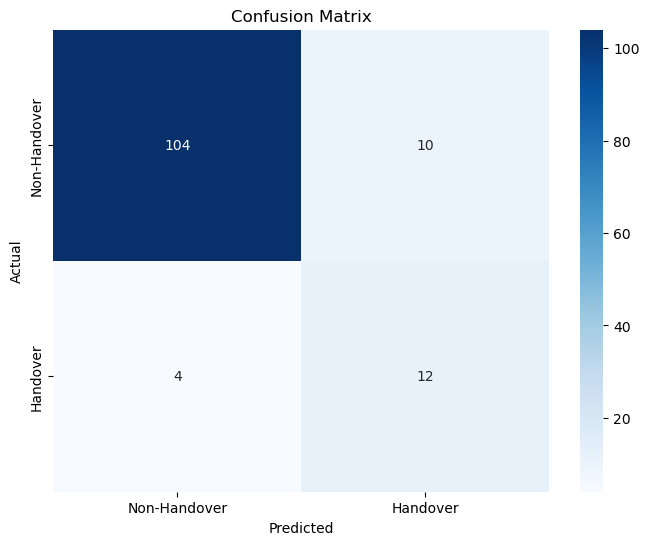

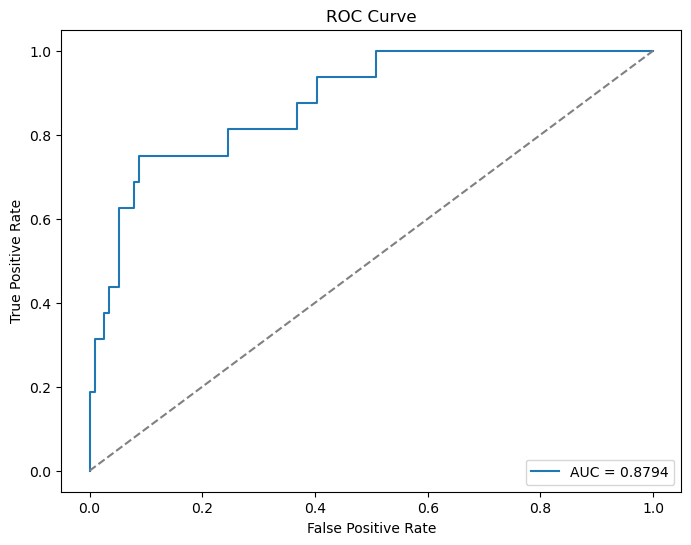

Log Loss: 0.2535


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM model with probability estimation enabled (important for adjusting thresholds)
svm_model = SVC(probability=True, random_state=42)

# Fit the model
svm_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class

# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")

KFOLD CROSS VALIDATION

In [27]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score
import numpy as np

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the SVM model with probability estimation enabled (important for adjusting thresholds)
svm_model = SVC(probability=True, random_state=42)

# Define Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

accuracy_scores = []
recall_scores = []

# Perform Stratified K-Fold cross-validation
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    svm_model.fit(X_train, y_train)

    # Predict probabilities on the test set
    y_prob = svm_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

    # Adjust the decision threshold (Th=0.3 instead of 0.5)
    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Calculate the mean and standard deviation for accuracy and recall
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print the formatted output

print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")
print(f"\nMean Accuracy: {mean_accuracy:.4f} | Std Accuracy: {std_accuracy:.4f}")
print(f"Mean Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f}")

Accuracy Scores: [0.9090909090909091, 0.8636363636363636, 0.8837209302325582, 0.9069767441860465, 0.9534883720930233, 0.8372093023255814, 0.8837209302325582, 0.9302325581395349, 0.8604651162790697, 0.9069767441860465, 0.8837209302325582, 0.8837209302325582, 0.8837209302325582, 0.813953488372093, 0.813953488372093]
Recall Scores: [0.7142857142857143, 0.7142857142857143, 0.6666666666666666, 0.5, 0.6666666666666666, 0.6666666666666666, 0.5, 0.5, 0.5, 0.8333333333333334, 0.6666666666666666, 0.6666666666666666, 0.5, 0.2857142857142857, 0.42857142857142855]

Mean Accuracy: 0.8810 | Std Accuracy: 0.0378
Mean Recall: 0.5873 | Std Recall: 0.1363


KNN

Threshold: 0.3
Accuracy: 0.8462
Precision: 0.4091
Recall: 0.5625
F1 Score: 0.4737
AUC: 0.8150


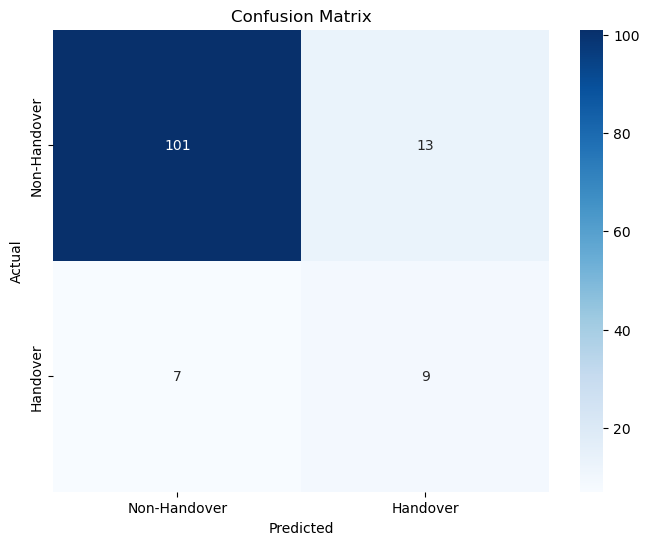

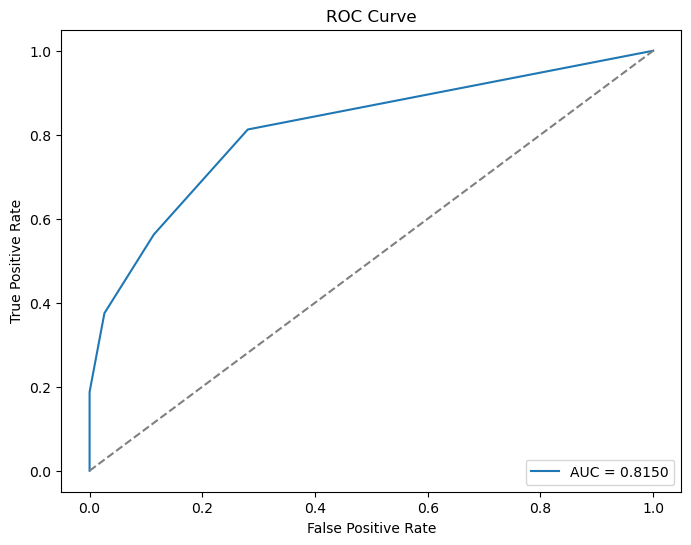

Log Loss: 1.0124


In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Fit the model
knn_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = knn_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class

# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")


KFOLD CROSS VALIDATION

In [68]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score
import numpy as np

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the KNN model (you can tune 'n_neighbors' parameter as needed)
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can experiment with different 'n_neighbors' values

# Define Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracy_scores = []
recall_scores = []

# Perform Stratified K-Fold cross-validation
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    knn_model.fit(X_train, y_train)

    # Predict probabilities on the test set
    y_prob = knn_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

    # Adjust the decision threshold (Th=0.3 instead of 0.5)
    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Calculate the mean and standard deviation for accuracy and recall
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print the formatted output

print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")
print(f"\nMean Accuracy: {mean_accuracy:.4f} | Std Accuracy: {std_accuracy:.4f}")
print(f"Mean Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f}")


Accuracy Scores: [0.8769230769230769, 0.8307692307692308, 0.9230769230769231, 0.8461538461538461, 0.8923076923076924, 0.8923076923076924, 0.8615384615384616, 0.859375, 0.828125, 0.8125]
Recall Scores: [0.6666666666666666, 0.4444444444444444, 0.4444444444444444, 0.5, 0.5, 0.7, 0.7, 0.5555555555555556, 0.4444444444444444, 0.5555555555555556]

Mean Accuracy: 0.8623 | Std Accuracy: 0.0326
Mean Recall: 0.5511 | Std Recall: 0.0985


In [ ]:
NAIVE BAYES

Threshold: 0.3
Accuracy: 0.9000
Precision: 0.6154
Recall: 0.5000
F1 Score: 0.5517
AUC: 0.8646


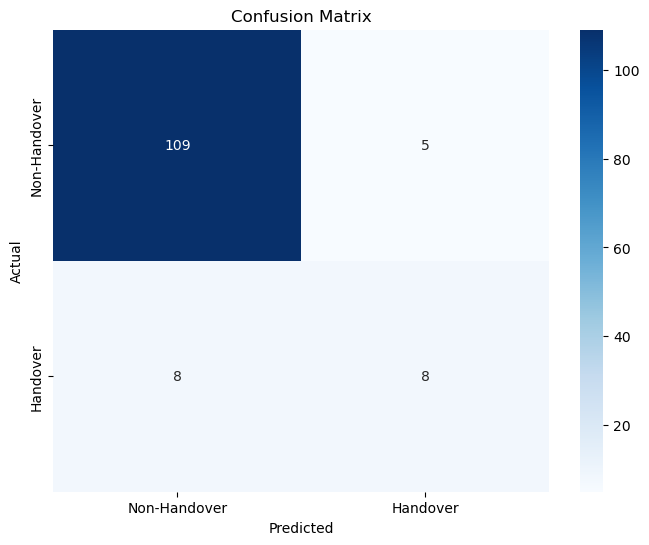

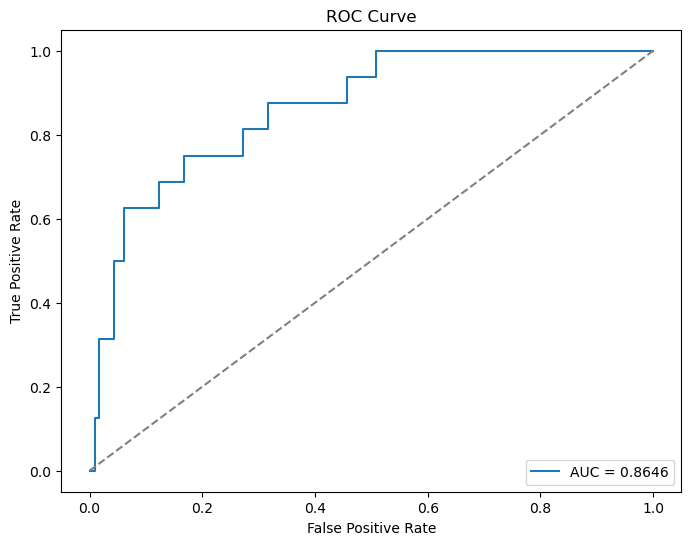

Log Loss: 0.2794


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Features
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing) using stratify to maintain the ratio of handovers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Naive Bayes model
nb_model = GaussianNB()

# Fit the model
nb_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class (handover)

# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results
print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")

In [ ]:
KFOLD CROSS VALIDATION

In [64]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score
import numpy as np

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the Naive Bayes model
nb_model = GaussianNB()

# Define Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

accuracy_scores = []
recall_scores = []

# Perform Stratified K-Fold cross-validation
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    nb_model.fit(X_train, y_train)

    # Predict probabilities on the test set
    y_prob = nb_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

    # Adjust the decision threshold (Th=0.3 instead of 0.5)
    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Calculate the mean and standard deviation for accuracy and recall
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print the formatted output
print(f"Threshold: {threshold}")
print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")
print(f"\nMean Accuracy: {mean_accuracy:.4f} | Std Accuracy: {std_accuracy:.4f}")
print(f"Mean Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f}")


Threshold: 0.3
Accuracy Scores: [0.8484848484848485, 0.8787878787878788, 0.8484848484848485, 0.8484848484848485, 0.8787878787878788, 0.8787878787878788, 0.8181818181818182, 0.875, 0.96875, 0.875, 0.90625, 0.90625, 0.96875, 0.90625, 0.875, 0.84375, 0.84375, 0.9375, 0.75, 0.84375]
Recall Scores: [0.4, 0.4, 0.6, 0.2, 0.4, 0.2, 0.2, 0.0, 0.75, 0.25, 0.25, 0.5, 0.75, 0.8, 0.4, 0.2, 0.2, 0.6, 0.2, 0.0]

Mean Accuracy: 0.8750 | Std Accuracy: 0.0492
Mean Recall: 0.3650 | Std Recall: 0.2319


ADABOOST

Accuracy: 0.8923
Precision: 0.5833
Recall: 0.4375
F1 Score: 0.5000
AUC: 0.7706


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


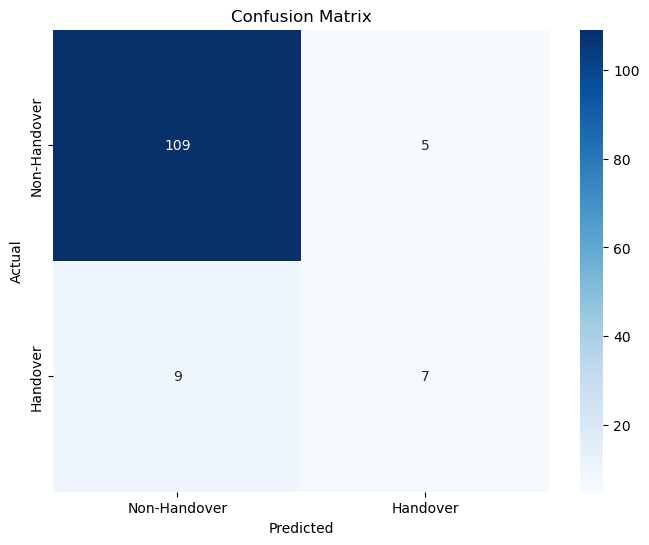

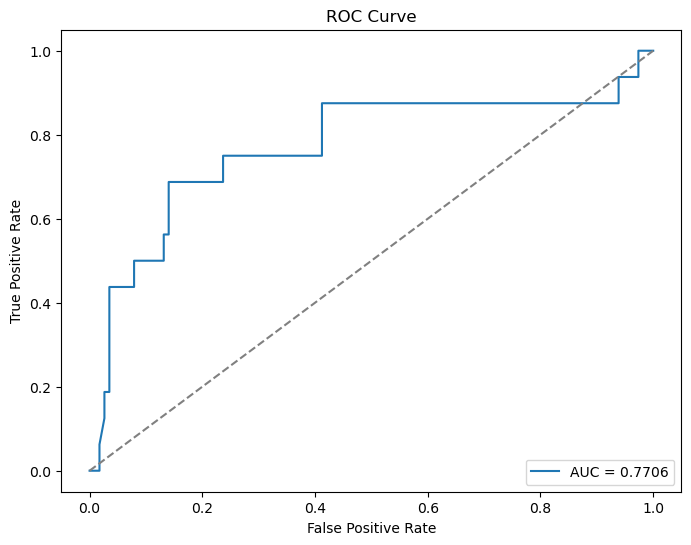

Log Loss: 0.6236


In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Features
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing) using stratify to maintain the ratio of handovers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the AdaBoost model
adaboost_model = AdaBoostClassifier(n_estimators=50 ,learning_rate= 1, random_state=42)n_estimators=30

# Fit the model
adaboost_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = adaboost_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class (handover)


threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error~
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")

KFOLD CROSS VALIDATION

In [56]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, recall_score
import numpy as np

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the AdaBoost model
ada_model = AdaBoostClassifier(random_state=42)

# Define Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracy_scores = []
recall_scores = []

# Perform Stratified K-Fold cross-validation
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    ada_model.fit(X_train, y_train)

    # Predict probabilities on the test set
    y_prob = ada_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

   
    threshold = 0.5
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Calculate the mean and standard deviation for accuracy and recall
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print the formatted output
print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")
print(f"\nMean Accuracy: {mean_accuracy:.4f} | Std Accuracy: {std_accuracy:.4f}")
print(f"Mean Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f}")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramDa

Accuracy Scores: [0.9230769230769231, 0.9076923076923077, 0.9076923076923077, 0.8615384615384616, 0.8615384615384616, 0.8923076923076924, 0.9076923076923077, 0.90625, 0.875, 0.828125]
Recall Scores: [0.5555555555555556, 0.6666666666666666, 0.4444444444444444, 0.2, 0.3, 0.4, 0.7, 0.6666666666666666, 0.4444444444444444, 0.2222222222222222]

Mean Accuracy: 0.8871 | Std Accuracy: 0.0281
Mean Recall: 0.4600 | Std Recall: 0.1749


GRADIENTBOOST

Accuracy: 0.8538
Precision: 0.5000
Recall: 0.4737
F1 Score: 0.4865
AUC: 0.8348


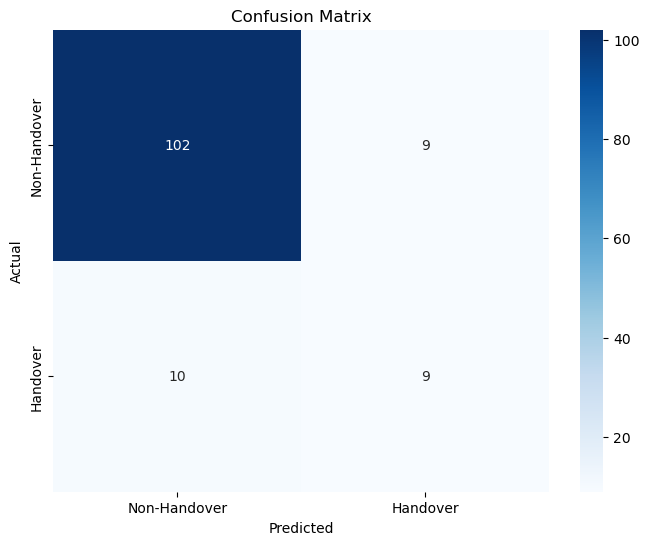

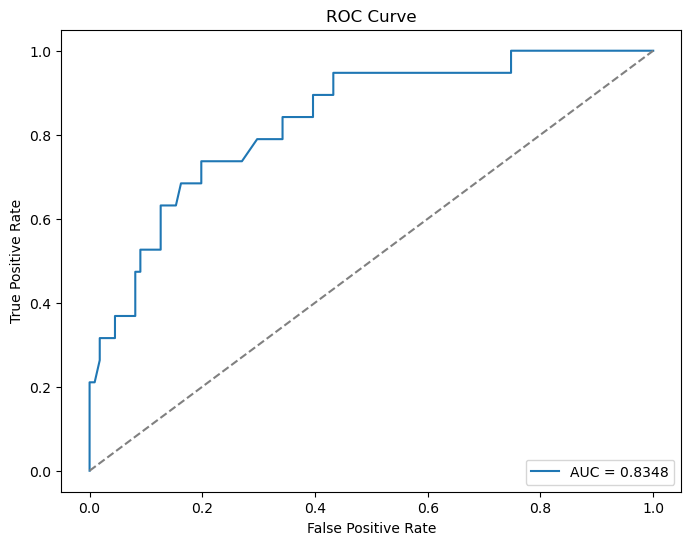

Log Loss: 0.3225


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Features
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing) using stratify to maintain the ratio of handovers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42) max_depth=2**

# Fit the model
gb_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = gb_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class (handover)

# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")


In [ ]:
KFOLD CROSS VALIDATION

In [54]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score
import numpy as np

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Define Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracy_scores = []
recall_scores = []

# Perform Stratified K-Fold cross-validation
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    gb_model.fit(X_train, y_train)

    # Predict probabilities on the test set
    y_prob = gb_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

    # Adjust the decision threshold (Th=0.3 instead of 0.5)
    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Calculate the mean and standard deviation for accuracy and recall
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print the formatted output
print(f"Threshold: {threshold}")
print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")
print(f"\nMean Accuracy: {mean_accuracy:.4f} | Std Accuracy: {std_accuracy:.4f}")
print(f"Mean Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f}")


Threshold: 0.3
Accuracy Scores: [0.9230769230769231, 0.8461538461538461, 0.9230769230769231, 0.8615384615384616, 0.8769230769230769, 0.9230769230769231, 0.8769230769230769, 0.890625, 0.84375, 0.8125]
Recall Scores: [0.7777777777777778, 0.5555555555555556, 0.5555555555555556, 0.7, 0.4, 0.7, 0.7, 0.6666666666666666, 0.5555555555555556, 0.4444444444444444]

Mean Accuracy: 0.8778 | Std Accuracy: 0.0361
Mean Recall: 0.6056 | Std Recall: 0.1166


XGBOOST

C:\Users\sdmns\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [00:49:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8538
Precision: 0.5000
Recall: 0.4211
F1 Score: 0.4571
AUC: 0.8440


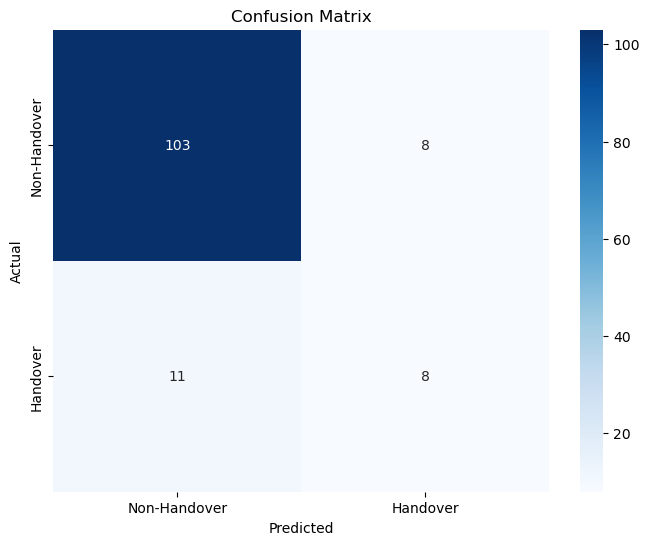

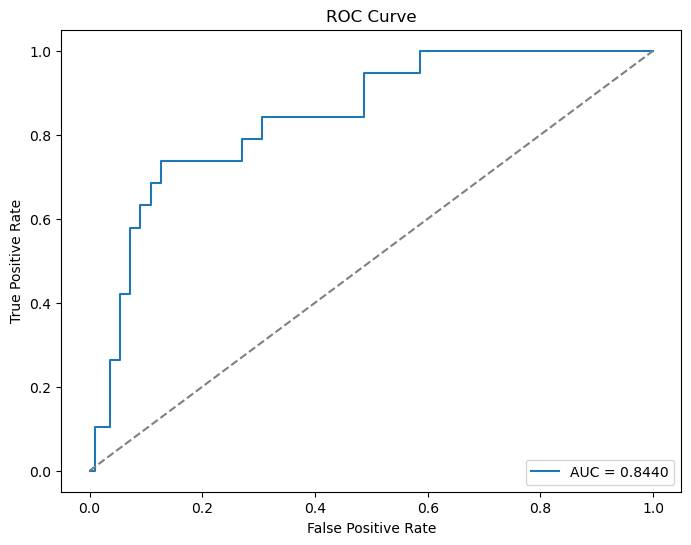

Log Loss: 0.4474


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Features
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Split data into training and testing sets (80% training, 20% testing) using stratify to maintain the ratio of handovers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost model
xgb_model = XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Fit the model
xgb_model.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class (handover)

# Adjust the decision threshold (example: 0.3 instead of 0.5)
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Evaluate the model with different metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Displaying results

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Handover", "Handover"], yticklabels=["Non-Handover", "Handover"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import log_loss

# Calculate the log loss error
log_loss_error = log_loss(y_test, y_prob)

# Display the log loss error
print(f"Log Loss: {log_loss_error:.4f}")

In [ ]:
KFOLD CROSS VALIDATION

In [16]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score
import numpy as np

# Load the dataset (replace 'Day2Data.csv' with your actual file path)
df = pd.read_csv('Day2Data.csv')

# Define features and target variable, including CINR
X = df[['PCellRSRP', 'PCellRSRQ', 'NeighCellRSRP', 'NeighCellRSRQ', 'CINR']]  # Including CINR as per request
y = df['Handover']  # Target variable (assuming 'Handover' is the column with 0 and 1 labels)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=15, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

accuracy_scores = []
recall_scores = []

# Perform Stratified K-Fold cross-validation
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    xgb_model.fit(X_train, y_train)

    # Predict probabilities on the test set
    y_prob = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

    # Adjust the decision threshold (Th=0.3 instead of 0.5)
    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate accuracy and recall
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)

# Calculate the mean and standard deviation for accuracy and recall
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

# Print the formatted output

print(f"Accuracy Scores: {accuracy_scores}")
print(f"Recall Scores: {recall_scores}")
print(f"\nMean Accuracy: {mean_accuracy:.4f} | Std Accuracy: {std_accuracy:.4f}")
print(f"Mean Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f}")


C:\Users\sdmns\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [00:56:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\sdmns\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [00:56:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\sdmns\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [00:56:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg,

Accuracy Scores: [0.9090909090909091, 0.8863636363636364, 0.8604651162790697, 0.9302325581395349, 0.9534883720930233, 0.8372093023255814, 0.8604651162790697, 0.9069767441860465, 0.8837209302325582, 0.8837209302325582, 0.8604651162790697, 0.8837209302325582, 0.9302325581395349, 0.7441860465116279, 0.813953488372093]
Recall Scores: [0.8571428571428571, 0.7142857142857143, 0.5, 0.6666666666666666, 0.8333333333333334, 0.6666666666666666, 0.5, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.5, 0.6666666666666666, 0.14285714285714285, 0.42857142857142855]

Mean Accuracy: 0.8763 | Std Accuracy: 0.0501
Mean Recall: 0.6095 | Std Recall: 0.1697


C:\Users\sdmns\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [00:56:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


MODEL COMPARISON

In [13]:
import pandas as pd

# Data for different models
data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes', 'AdaBoost', 'GradientBoost', 'XGBoost'],
    'Accuracy': [0.8846, 0.8615, 0.8692, 0.8923, 0.8462, 0.9000, 0.8923, 0.8462, 0.8692],
    'Precision': [0.5238, 0.4286, 0.5455, 0.5455, 0.4091, 0.6154, 0.5833, 0.4737, 0.5455],
    'Recall': [0.6875, 0.3750, 0.6316, 0.7500, 0.5625, 0.5000, 0.4375, 0.4737, 0.6316],
    'F1 Score': [0.5946, 0.4000, 0.5854, 0.6316, 0.4737, 0.5517, 0.5000, 0.4737, 0.5854],
    'AUC': [0.8871, 0.6524, 0.8528, 0.8794, 0.8150, 0.8646, 0.7706, 0.8402, 0.8440],
    'Log Loss': [0.2374, 4.9907, 0.3048, 0.2535, 1.0124, 0.2794, 0.6236, 0.3474, 0.4474]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

,Model,Accuracy,Precision,Recall,F1 Score,AUC,Log Loss
0,Logistic Regression,0.8846,0.5238,0.6875,0.5946,0.8871,0.2374
1,Decision Tree,0.8615,0.4286,0.3750,0.4000,0.6524,4.9907
2,Random Forest,0.8692,0.5455,0.6316,0.5854,0.8528,0.3048
3,SVM,0.8923,0.5455,0.7500,0.6316,0.8794,0.2535
4,KNN,0.8462,0.4091,0.5625,0.4737,0.8150,1.0124
5,Naive Bayes,0.9000,0.6154,0.5000,0.5517,0.8646,0.2794
6,AdaBoost,0.8923,0.5833,0.4375,0.5000,0.7706,0.6236
7,GradientBoost,0.8462,0.4737,0.4737,0.4737,0.8402,0.3474
8,XGBoost,0.8692,0.5455,0.6316,0.5854,0.8440,0.4474
